In [2]:
import pandas as pd
import sqlite3
import numpy as np
import statsmodels.api as sm

conn = sqlite3.connect("Insurance_project.db")

query = """
SELECT 
    p.customerid,
    u.age,
    u.location,
    u.gender,
    p.coveragetype,
    p.lengthofpolicy,
    COUNT(c.claimsid) AS claim_count
FROM policy p

LEFT JOIN claims c
    ON p.policyid = c.policyid

INNER JOIN customers u
    ON p.customerid = u.customerid

GROUP BY
    p.customerid,
    u.age,
    u.location,
    u.gender,
    p.coveragetype,
    p.lengthofpolicy
"""

df = pd.read_sql_query(query, conn)

conn.close()


# DATA PREPARATION


df.columns = [
    "customer_id",
    "age",
    "location",
    "gender",
    "coverage",
    "policy_length",
    "claim_count"
]

# Ensure numeric types
df["claim_count"] = pd.to_numeric(df["claim_count"])
df["policy_length"] = pd.to_numeric(df["policy_length"])
df["age"] = pd.to_numeric(df["age"])


df = df[df["policy_length"] > 0]
# Feature matrix
X = df[[
    "age",
    "gender",
    "coverage"
]]

X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)
X = sm.add_constant(X)

# Target
y = df["claim_count"]

# Exposure
exposure = np.log(df["policy_length"])

# Fit Poisson model
poisson_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
    offset=exposure
)

result = poisson_model.fit()

# Predictions
df["predicted_claim_frequency"] = result.predict(
    X,
    offset=exposure
)

# Dispersion check
dispersion = result.pearson_chi2 / result.df_resid

print(
    "\nDispersion Statistic:",
    round(dispersion, 3)
)
# MODEL SUMMARY


print("\n===== POISSON MODEL SUMMARY =====\n")
print(result.summary())


# DISPERSION CHECK


print("\n===== DISPERSION CHECK =====\n")

print("Mean Claim Count:", y.mean())
print("Variance Claim Count:", y.var())

if y.var() > y.mean() * 2:
    print("Possible overdispersion detected.")
else:
    print("Poisson variance assumption appears reasonable.")


# EXPONENTIATED COEFFICIENTS


print("\n===== RISK MULTIPLIERS =====\n")

risk_multipliers = np.exp(result.params)

print(risk_multipliers)


# PREDICTIONS


df["predicted_claim_frequency"] = result.predict(
    X,
    offset=np.log(df["policy_length"])
)

print("\n===== SAMPLE PREDICTIONS =====\n")

print(df[[
    "customer_id",
    "claim_count",
    "predicted_claim_frequency"
]].head())




Dispersion Statistic: 1.603

===== POISSON MODEL SUMMARY =====

                 Generalized Linear Model Regression Results                  
Dep. Variable:            claim_count   No. Observations:                13001
Model:                            GLM   Df Residuals:                    12996
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8399.4
Date:                Thu, 11 Jun 2026   Deviance:                       11674.
Time:                        16:04:43   Pearson chi2:                 2.08e+04
No. Iterations:                     6   Pseudo R-squ. (CS):          0.0005899
Covariance Type:            nonrobust                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

**Conclusion**
The Poisson frequency model estimates the number of claims per policy and finds that claim frequency is generally low, with an average predicted rate of about 0.24 claims per policy.

Model diagnostics show mild overdispersion (dispersion statistic = 1.60), but the mean and variance are relatively close, so the Poisson assumption appears broadly reasonable.

Among the predictors, only gender was statistically significant: male policyholders had approximately 7.5% higher expected claim frequency than the reference group. Age had a small negative effect but was not significant, and neither Third Party nor Third Party, Fire and Theft coverage types showed a significant impact on claim frequency.

Overall, the model suggests that claim frequency varies little across the available predictors, with most policies expected to have fewer than one claim during the observation period.

In [5]:
import pandas as pd
import sqlite3
import numpy as np
import statsmodels.api as sm


conn = sqlite3.connect("Insurance_project.db")

query = """
SELECT
    p.customerid,
    cst.age,
    cst.gender,
    p.coveragetype,
    COUNT(cl.claimsid) AS number_of_claims,
    SUM(cl.amount) AS total_claim_amount,
    AVG(cl.amount) AS avg_claim_amount
FROM policy p

INNER JOIN customers cst
    ON p.customerid = cst.customerid

LEFT JOIN claims cl
    ON p.policyid = cl.policyid
    AND cl.amount > 0

GROUP BY
    p.customerid,
    cst.age,
    cst.gender,
    p.coveragetype
"""

df = pd.read_sql_query(query, conn)

conn.close()

# DATA PREPARATION


df.columns = [
    "customer_id",
    "age",
    "gender",
    "coverage_type",
    "number_of_claims",
    "total_claim_amount",
    "avg_claim_amount"
]

# Convert numeric fields
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["number_of_claims"] = pd.to_numeric(
    df["number_of_claims"],
    errors="coerce"
).fillna(0)

df["avg_claim_amount"] = pd.to_numeric(
    df["avg_claim_amount"],
    errors="coerce"
)


# SEVERITY DATASET


df_sev = df.copy()

df_sev = df_sev[
    (df_sev["number_of_claims"] > 0)
    & (df_sev["avg_claim_amount"] > 0)
]


# DEFINE TARGET


y = df_sev["avg_claim_amount"]


# FEATURE MATRIX


X = df_sev[[
    "age",
    "gender",
    "coverage_type",
    "number_of_claims"
]]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)


X = X.astype(float)

# Add intercept
X = sm.add_constant(X)


# GAMMA GLM (SEVERITY MODEL)


severity_model = sm.GLM(
    y,
    X,
    family=sm.families.Gamma(
        link=sm.families.links.Log()
    )
)

result = severity_model.fit()


# OUTPUT RESULTS


print("\n===== SEVERITY MODEL SUMMARY =====\n")
print(result.summary())

print("\n===== SEVERITY RISK MULTIPLIERS =====\n")
print(np.exp(result.params))


# PREDICTIONS


df_sev["predicted_severity"] = result.predict(X)

print("\n===== SAMPLE PREDICTIONS =====\n")

print(
    df_sev[[
        "customer_id",
        "avg_claim_amount",
        "predicted_severity"
    ]].head()
)


===== SEVERITY MODEL SUMMARY =====

                 Generalized Linear Model Regression Results                  
Dep. Variable:       avg_claim_amount   No. Observations:                 1503
Model:                            GLM   Df Residuals:                     1497
Model Family:                   Gamma   Df Model:                            5
Link Function:                    Log   Scale:                          2.8619
Method:                          IRLS   Log-Likelihood:                -15139.
Date:                Thu, 11 Jun 2026   Deviance:                       2655.2
Time:                        16:22:08   Pearson chi2:                 4.28e+03
No. Iterations:                    12   Pseudo R-squ. (CS):            0.01959
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

**Conclusion**
The Gamma GLM severity model estimates the average cost of claims and indicates that most predictor variables have limited influence on claim severity. Age, number of claims, gender, and standard Third Party coverage were not statistically significant predictors of claim amount. However, customers with Third Party, Fire and Theft coverage had significantly higher claim severities, with expected claim costs approximately 49% higher than the reference coverage type.

The model's baseline predicted claim severity is approximately £9,090, with claim costs varying according to customer and policy characteristics. Despite identifying a significant effect for coverage type, the model has a relatively low explanatory power (Pseudo R² ≈ 0.02), suggesting that much of the variation in claim severity is driven by factors not included in the model.

Overall, the results indicate that policy coverage type is the primary driver of claim severity within the available predictors, while demographic and claim-count variables have little impact on the average claim amount.

risk_band
Low Risk       4106
High Risk      4101
Medium Risk    4096
Name: count, dtype: int64


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


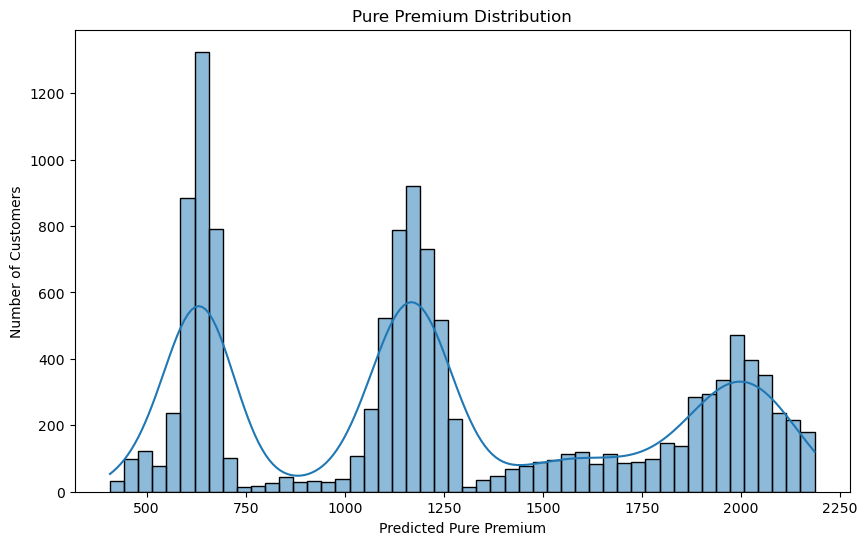

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


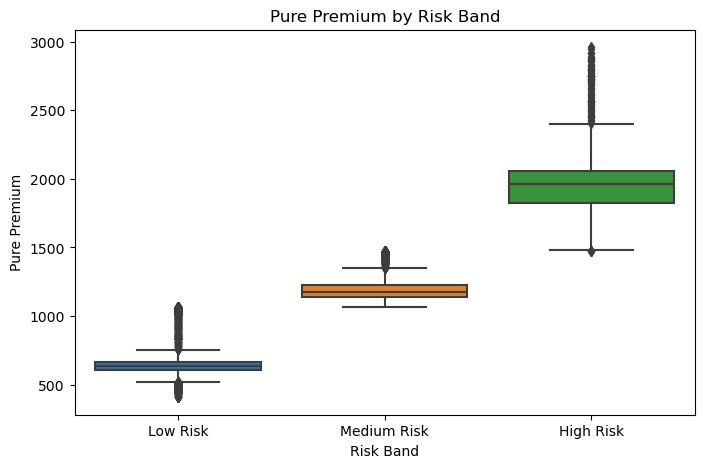

In [4]:

# IMPORTS


import pandas as pd
import sqlite3
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns



# LOAD DATA 

conn = sqlite3.connect("Insurance_project.db")

query = """
SELECT 
    p.customerid,
    cst.age,
    cst.gender,
    p.coveragetype,
    COUNT(cl.claimsid) AS number_of_claims,
    SUM(cl.amount) AS total_claim_amount,
    AVG(cl.amount) AS avg_claim_amount
FROM policy p

LEFT JOIN claims cl
    ON p.policyid = cl.policyid
    AND cl.amount > 0

INNER JOIN customers cst
    ON p.customerid = cst.customerid

GROUP BY 
    p.customerid,
    cst.age,
    cst.gender,
    p.coveragetype;
"""

df = pd.read_sql_query(query, conn)
conn.close()



# CLEAN DATA


df.columns = [
    "customer_id",
    "age",
    "gender",
    "coverage_type",
    "number_of_claims",
    "total_claim_amount",
    "avg_claim_amount"
]

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["number_of_claims"] = pd.to_numeric(df["number_of_claims"], errors="coerce").fillna(0)
df["avg_claim_amount"] = pd.to_numeric(df["avg_claim_amount"], errors="coerce")

df = df[df["age"].notnull()]
df = df[df["coverage_type"].notnull()]



# FREQUENCY MODEL (POISSON)


freq_df = df.copy()

freq_X = freq_df[["age", "gender", "coverage_type"]]
freq_X = pd.get_dummies(freq_X, drop_first=True)
freq_X = sm.add_constant(freq_X).astype(float)

y_freq = freq_df["number_of_claims"].astype(float)

freq_model = sm.GLM(
    y_freq,
    freq_X,
    family=sm.families.Poisson()
)

freq_result = freq_model.fit()

freq_df["predicted_claim_frequency"] = freq_result.predict(freq_X)



# SEVERITY MODEL (GAMMA)



sev_df = df[df["number_of_claims"] > 0].copy()

sev_X = sev_df[[
    "age",
    "gender",
    "coverage_type",
    "number_of_claims"
]]

sev_X = pd.get_dummies(sev_X, drop_first=True)
sev_X = sm.add_constant(sev_X).astype(float)

y_sev = sev_df["avg_claim_amount"].astype(float)

sev_model = sm.GLM(
    y_sev,
    sev_X,
    family=sm.families.Gamma(link=sm.families.links.Log())
)

sev_result = sev_model.fit()

sev_df["predicted_severity"] = sev_result.predict(sev_X)



# MERGE RESULTS


df = freq_df.merge(
    sev_df[["customer_id", "predicted_severity"]],
    on="customer_id",
    how="left"
)

# Fill missing severity for non-claimants 
df["predicted_severity"] = df["predicted_severity"].fillna(
    sev_df["avg_claim_amount"].mean()
)



# PURE PREMIUM

df["pure_premium"] = (
    df["predicted_claim_frequency"] *
    df["predicted_severity"]
)



# RISK BANDS


df["risk_band"] = pd.qcut(
    df["pure_premium"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print(df["risk_band"].value_counts())



# PURE PREMIUM DISTRIBUTION


pp = df["pure_premium"]
pp = pp[pp < pp.quantile(0.99)]

plt.figure(figsize=(10,6))
sns.histplot(pp, bins=50, kde=True)

plt.title("Pure Premium Distribution")
plt.xlabel("Predicted Pure Premium")
plt.ylabel("Number of Customers")
plt.show()



# RISK BAND VISUALISATION


plt.figure(figsize=(8,5))

sns.boxplot(
    x="risk_band",
    y="pure_premium",
    data=df,
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Pure Premium by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Pure Premium")

plt.show()

**Conclusion**

The predicted pure premiums show clear separation across risk bands, with premiums increasing from Low Risk to High Risk customers. A distinct low-premium cluster represents policyholders with no prior claims, highlighting the importance of claim history in pricing. While premiums generally rise with risk level, the presence of outliers and variation within each band indicates that additional customer characteristics also influence the final premium. Overall, the model effectively differentiates between risk levels while capturing individual risk differences.